# Forecast VAR deck experiments

This notebook backs the technical slide deck **Forecast VAR — Agent Engineering for World Cup Forecasting**.

The storyline is deliberately split in two:

1. **Football drama first:** show match, group, knockout, and champion probabilities.
2. **Agent engineering second:** trace the full pipeline from sources → RAG → Skills → MCP → deterministic tools → typed claims → verifier → evaluation harness.

The notebook uses the offline deterministic project artifacts so it is reproducible without OpenAI API calls. The live path in the project defaults to `gpt-5.4-nano`, but the forecasting probabilities are generated by Python tools, not by asking the model to guess.

In [1]:
from pathlib import Path
import json, sys, pandas as pd
from IPython.display import display, Image, Markdown

ROOT = Path(r"/mnt/data/wc26_slide_work")
PROJECT = Path(r"/mnt/data/wc26_slide_work/wc26-forecast-var-agent-episode2-source-aware-gpt54nano")
FIGS = ROOT / "deck_figures"
ASSETS = ROOT / "assets"

sys.path.insert(0, str(PROJECT / "src"))

story = json.loads((ROOT / "forecast_story_data.json").read_text())
print("Project:", PROJECT.name)
print("Slides data file:", ROOT / "forecast_story_data.json")
print("Champion in approximate most-likely path:", story["approx_champion"])

Project: wc26-forecast-var-agent-episode2-source-aware-gpt54nano
Slides data file: /mnt/data/wc26_slide_work/forecast_story_data.json
Champion in approximate most-likely path: Argentina


## 1. The hook: who does Forecast VAR pick?

The first slides show predictions before explaining how they were created. This is what gives the YouTube session a strong opening: viewers see the forecast, then we reverse-engineer the agent pipeline behind it.

In [2]:
champions = pd.DataFrame(story["sim"]["top_teams"][:10])
champions_display = champions[["team", "group_winner", "round32", "round16", "quarterfinal", "semifinal", "final", "champion"]].copy()
for col in champions_display.columns[1:]:
    champions_display[col] = (champions_display[col] * 100).round(1).astype(str) + "%"
display(champions_display)

,team,group_winner,round32,round16,quarterfinal,semifinal,final,champion
0,Argentina,71.2%,96.8%,76.3%,67.0%,52.8%,35.5%,21.7%
1,France,67.0%,96.5%,73.2%,60.7%,44.3%,26.7%,13.7%
2,Spain,68.7%,95.8%,69.0%,55.8%,40.2%,23.5%,13.0%
3,England,64.0%,93.8%,69.0%,52.5%,35.7%,22.0%,11.8%
4,Portugal,61.2%,95.0%,69.3%,53.2%,30.2%,16.3%,8.7%
5,Brazil,62.3%,94.7%,67.5%,48.5%,27.8%,13.5%,6.8%
6,Netherlands,58.5%,91.3%,58.2%,37.8%,20.0%,9.3%,4.7%
7,Belgium,58.3%,92.3%,62.0%,38.8%,22.0%,8.8%,3.7%
8,Germany,61.8%,95.3%,66.2%,43.2%,19.7%,8.2%,3.0%
9,Uruguay,23.5%,88.8%,47.3%,24.2%,9.8%,4.0%,2.2%


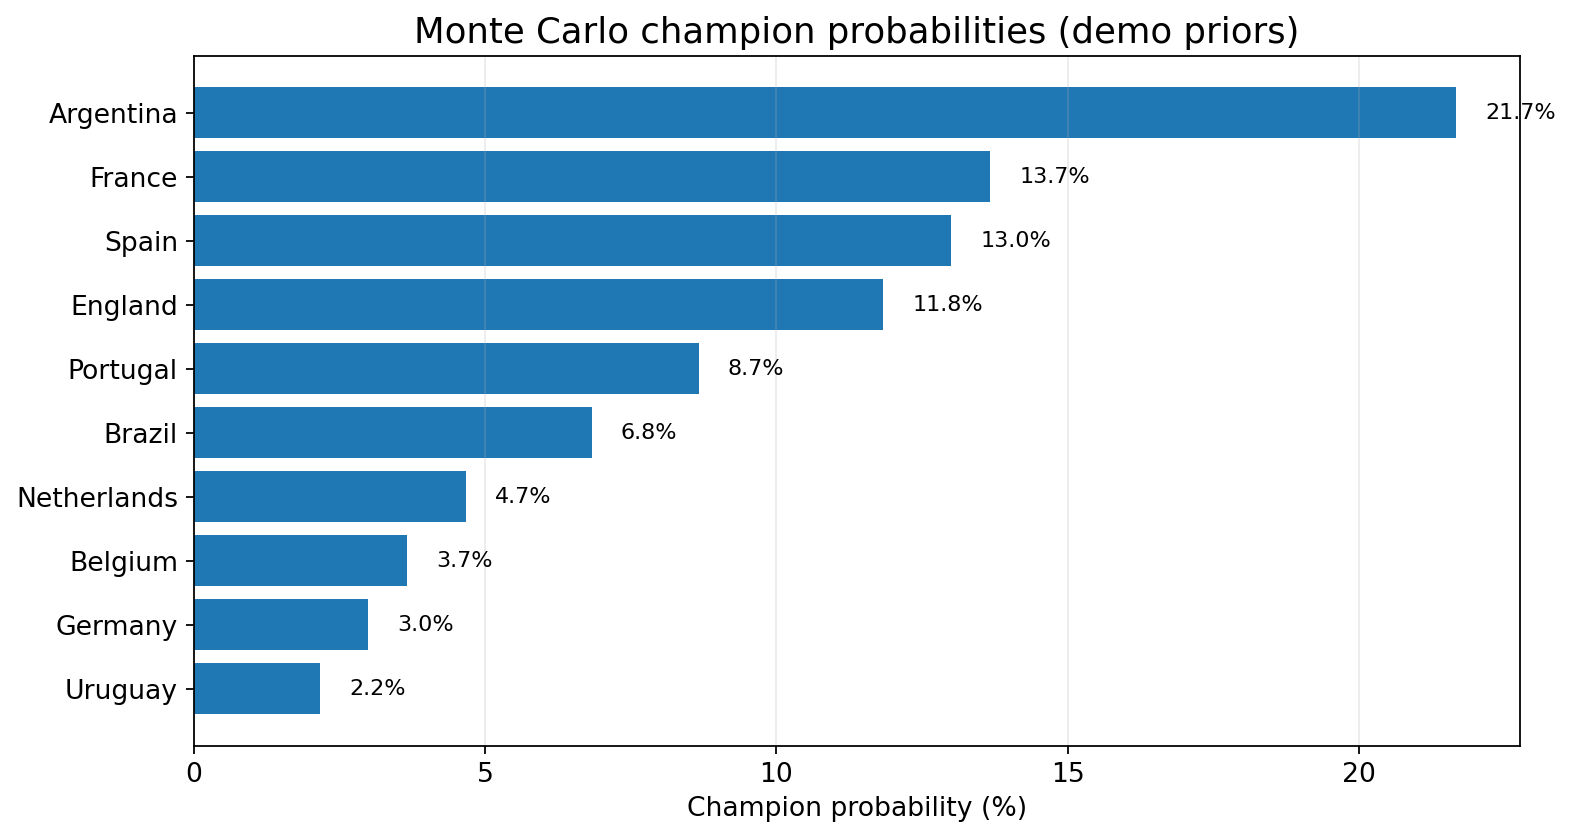

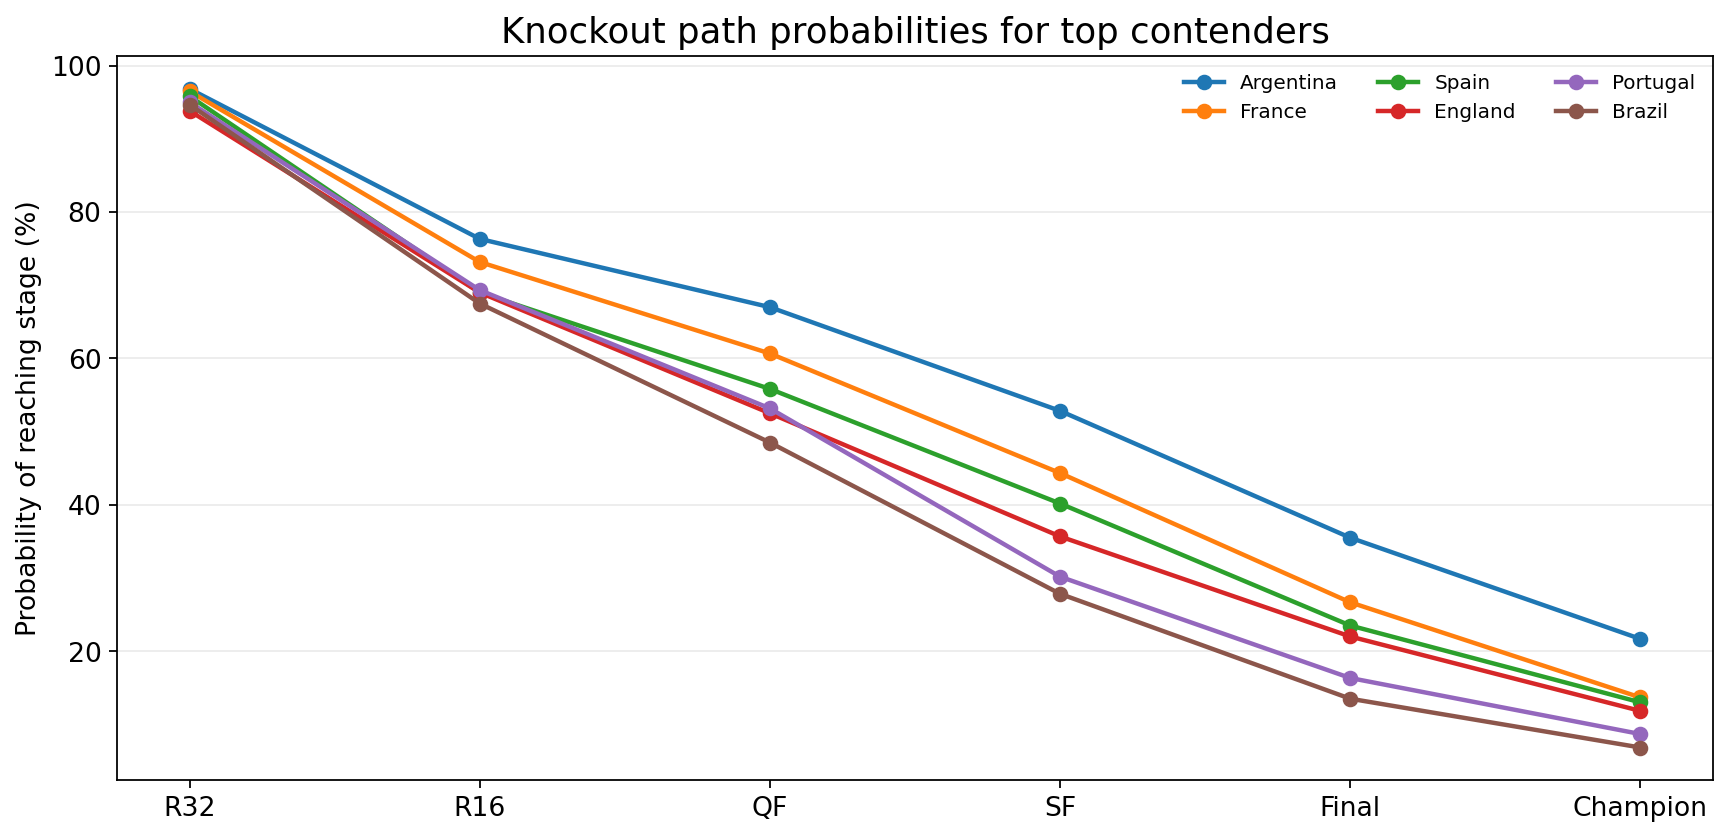

In [3]:
display(Image(filename=str(FIGS / "mc_champion_probs_wide.png")))
display(Image(filename=str(FIGS / "knockout_stage_funnel.png")))

The important wording is **not** “the agent knows who will win.” The correct wording is:

> Under the bundled demo priors and educational simulator, Argentina is the top modelled champion probability.

That phrasing is an Agent Engineering requirement: future events are not factual claims; they are model-derived claims.

## 2. Group winners and game-level forecasts

The deck next moves from tournament-level drama to group-stage detail. Each group forecast is produced by simulating the six round-robin matches inside the group.

In [4]:
group_winners = pd.DataFrame(story["most_likely_group_winners"])
group_winners["winner_prob"] = (group_winners["winner_prob"] * 100).round(1)
display(group_winners.rename(columns={"group":"Group", "team":"Most likely winner", "winner_prob":"Winner probability (%)"}))

,Group,Most likely winner,Winner probability (%)
0,A,Mexico,51.1
1,B,Switzerland,47.2
2,C,Brazil,62.8
3,D,USA,49.8
4,E,Germany,59.6
5,F,Netherlands,59.3
6,G,Belgium,64.0
7,H,Spain,67.4
8,I,France,70.5
9,J,Argentina,72.0


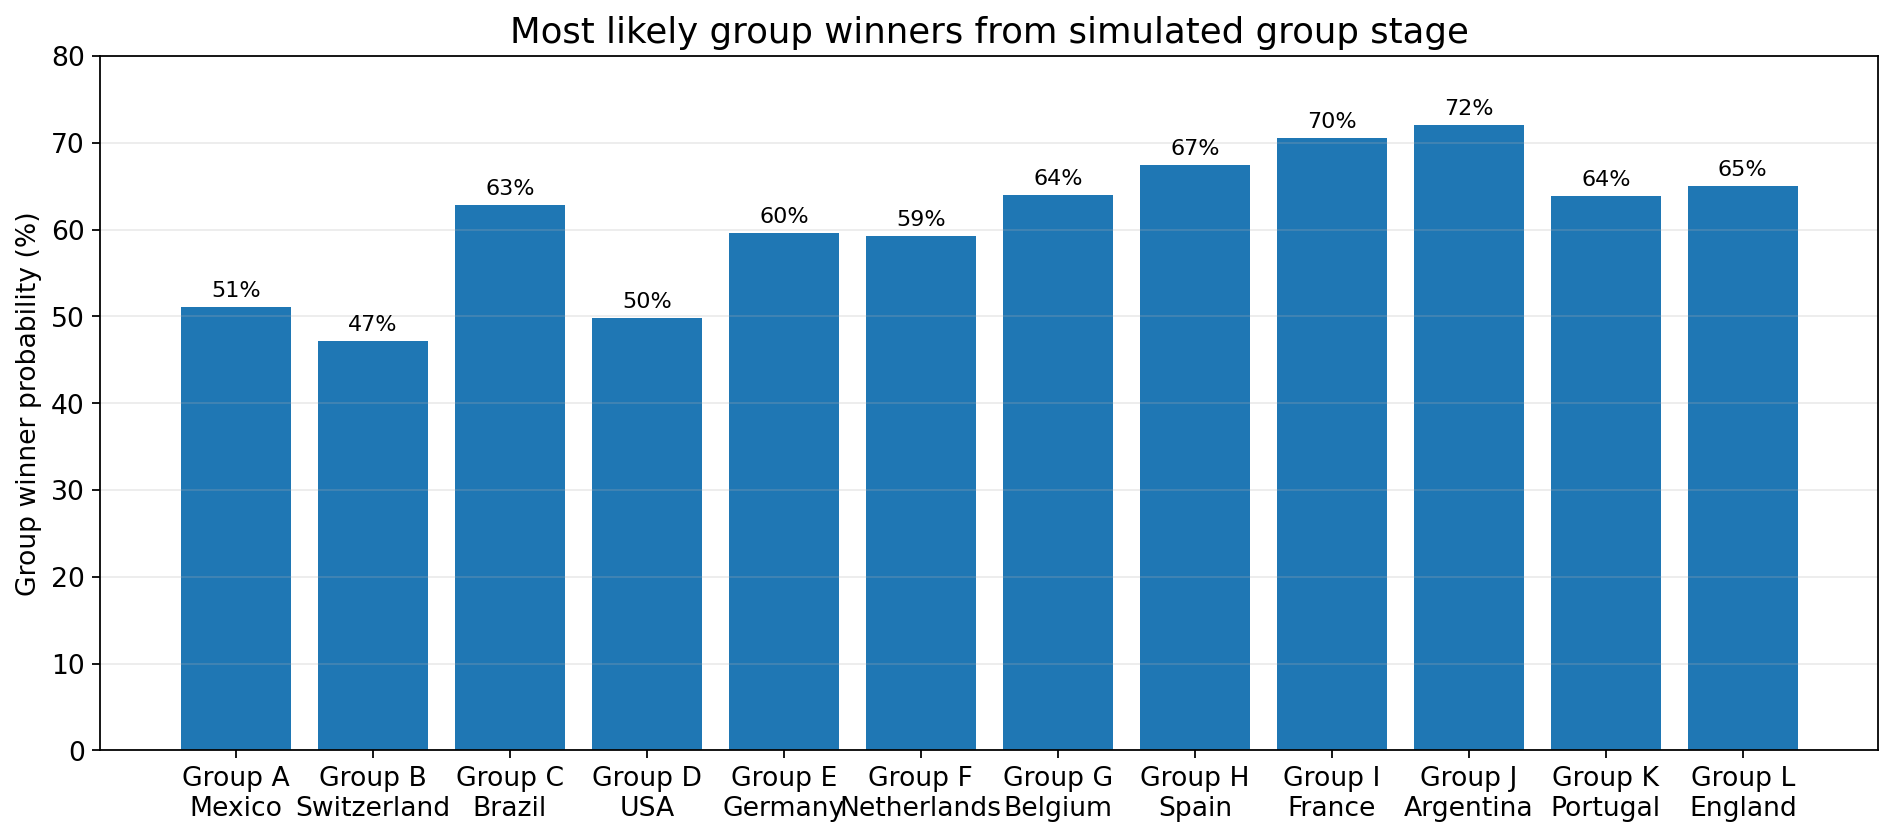

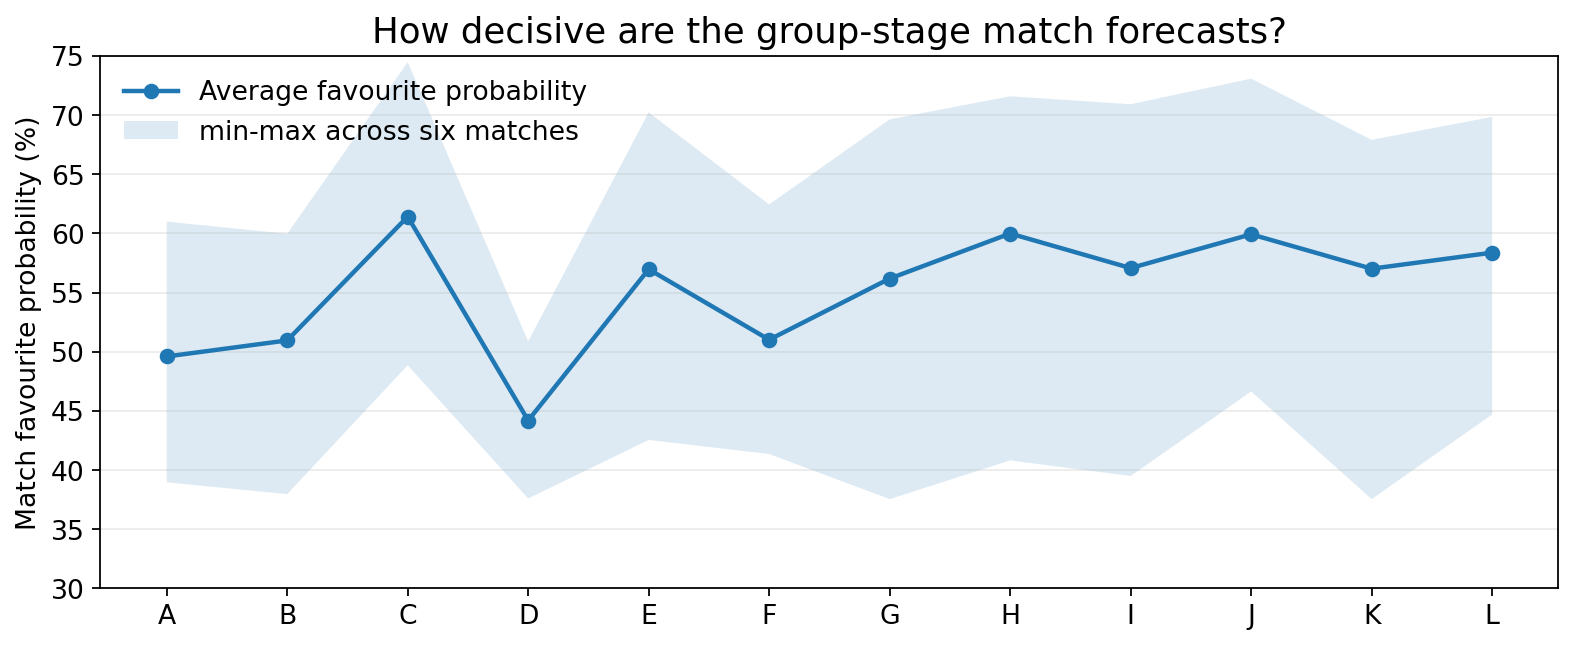

In [5]:
display(Image(filename=str(FIGS / "all_group_winners.png")))
display(Image(filename=str(FIGS / "group_match_confidence.png")))

In [6]:
match_forecasts = pd.DataFrame(story["match_forecasts"])
# Show a compact sample: Group D, because it contains USA, Paraguay, Australia, Türkiye.
group_d = match_forecasts[match_forecasts["group"] == "D"][["team_a", "team_b", "p_a", "p_draw", "p_b", "pick", "pick_p"]].copy()
for c in ["p_a", "p_draw", "p_b", "pick_p"]:
    group_d[c] = (group_d[c] * 100).round(1).astype(str) + "%"
display(group_d)

,team_a,team_b,p_a,p_draw,p_b,pick,pick_p
18,USA,Paraguay,49.7%,21.5%,28.8%,USA,49.7%
19,USA,Australia,50.9%,21.0%,28.1%,USA,50.9%
20,USA,Türkiye,46.3%,22.9%,30.8%,USA,46.3%
21,Paraguay,Australia,37.6%,26.5%,35.9%,Paraguay,37.6%
22,Paraguay,Türkiye,34.6%,25.6%,39.7%,Türkiye,39.7%
23,Australia,Türkiye,34.0%,25.1%,40.9%,Türkiye,40.9%


## 3. Knockout path and champion story

The deck includes an approximate most-likely seeded knockout path. This is intentionally labelled as an educational approximation. A reliable agent must disclose bracket simplifications instead of presenting them as official structure.

In [7]:
for rnd in story["approx_bracket_path"][-3:]:
    display(Markdown(f"### {rnd['round']}"))
    display(pd.DataFrame(rnd["matches"]))

### Quarterfinal

,a,b,winner,winner_prob
0,Argentina,Germany,Argentina,0.621
1,France,Netherlands,France,0.601
2,Spain,Brazil,Spain,0.543
3,England,Portugal,England,0.521


### Semifinal

,a,b,winner,winner_prob
0,Argentina,England,Argentina,0.541
1,France,Spain,France,0.514


### Final

,a,b,winner,winner_prob
0,Argentina,France,Argentina,0.514


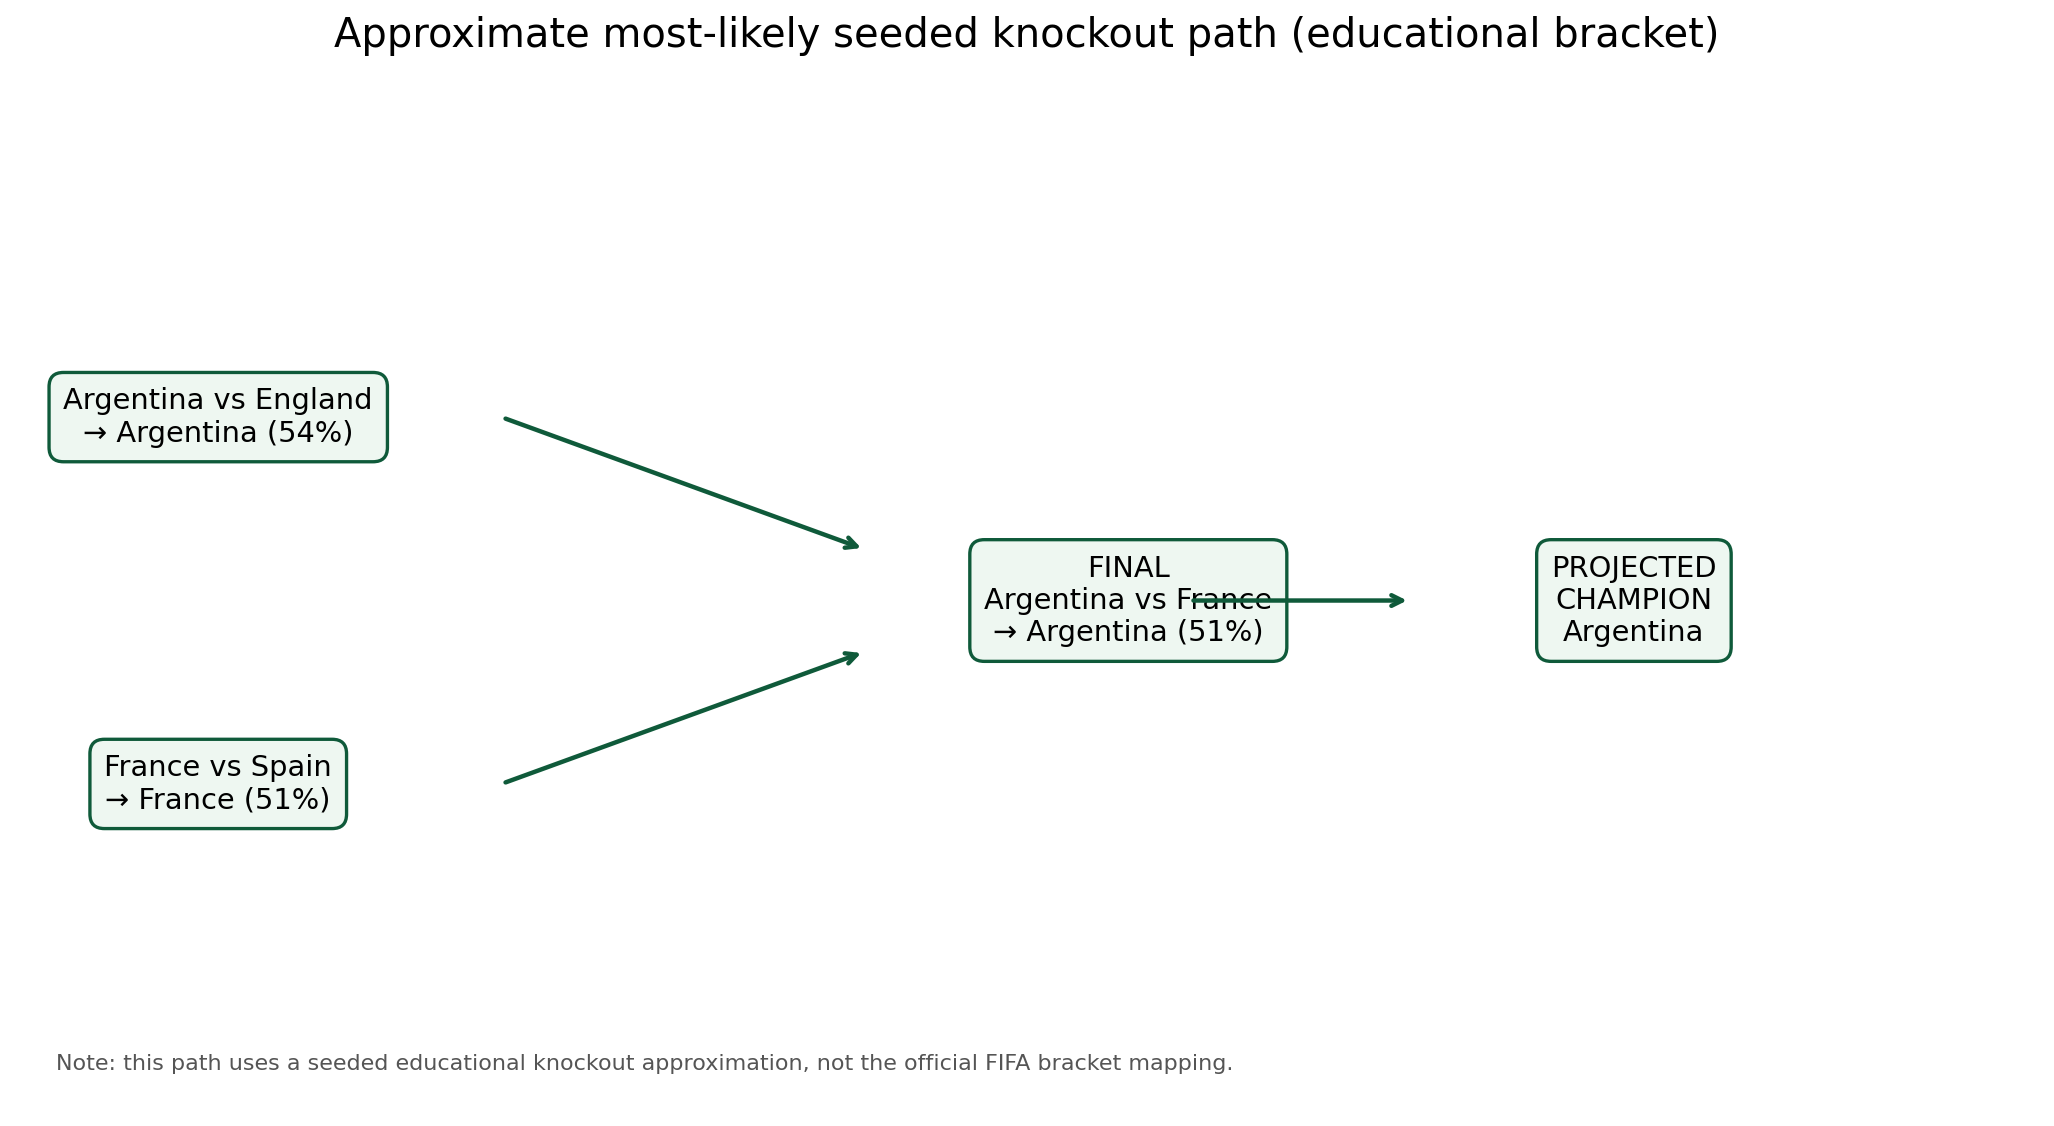

In [8]:
display(Image(filename=str(FIGS / "approx_bracket_path.png")))

## 4. The core architecture: gpt-5.4-nano is the orchestrator, not the simulator

The deck makes this distinction visually:

- `gpt-5.4-nano` chooses skills, calls tools, explains outputs, and formats claims.
- Python tools validate data, retrieve evidence, compute match probabilities, run Monte Carlo simulations, and verify claims.
- MCP is the tool boundary between them.

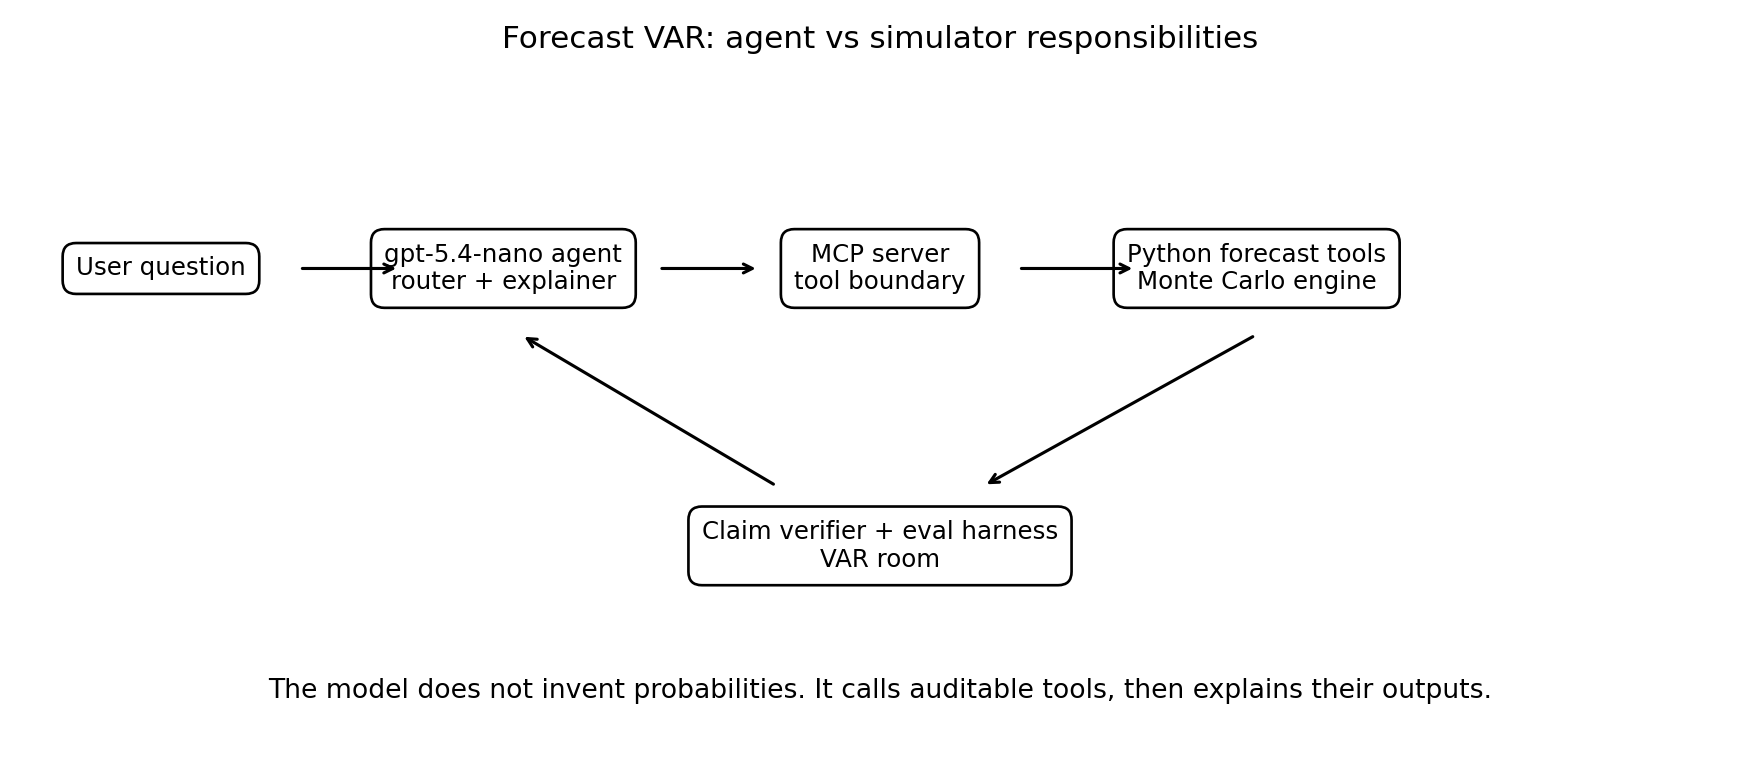

In [9]:
display(Image(filename=str(ROOT.parent / "agent_vs_simulator_pipeline.png")))

## 5. Pre-flight gate

Before a prediction is allowed, the agent checks whether the tournament field, feature table, source registry, and evidence index are internally coherent.

In [10]:
preflight = story["preflight"]
keys = ["ready_for_forecast", "field_valid", "group_count", "team_count", "unique_team_count", "feature_rows", "evidence_document_count", "blocked_reason"]
display(pd.DataFrame([{k: preflight.get(k) for k in keys}]).T.rename(columns={0:"value"}))
print("Warnings:")
for w in preflight["warnings"]:
    print("-", w)

,value
ready_for_forecast,True
field_valid,True
group_count,12
team_count,48
unique_team_count,48
feature_rows,48
evidence_document_count,74
blocked_reason,None


Warnings:
- Forecasts use bundled demo priors unless adapters are refreshed.
- Do not forecast teams outside the validated 48-team field.
- Do not convert model probabilities into certainty or betting advice.


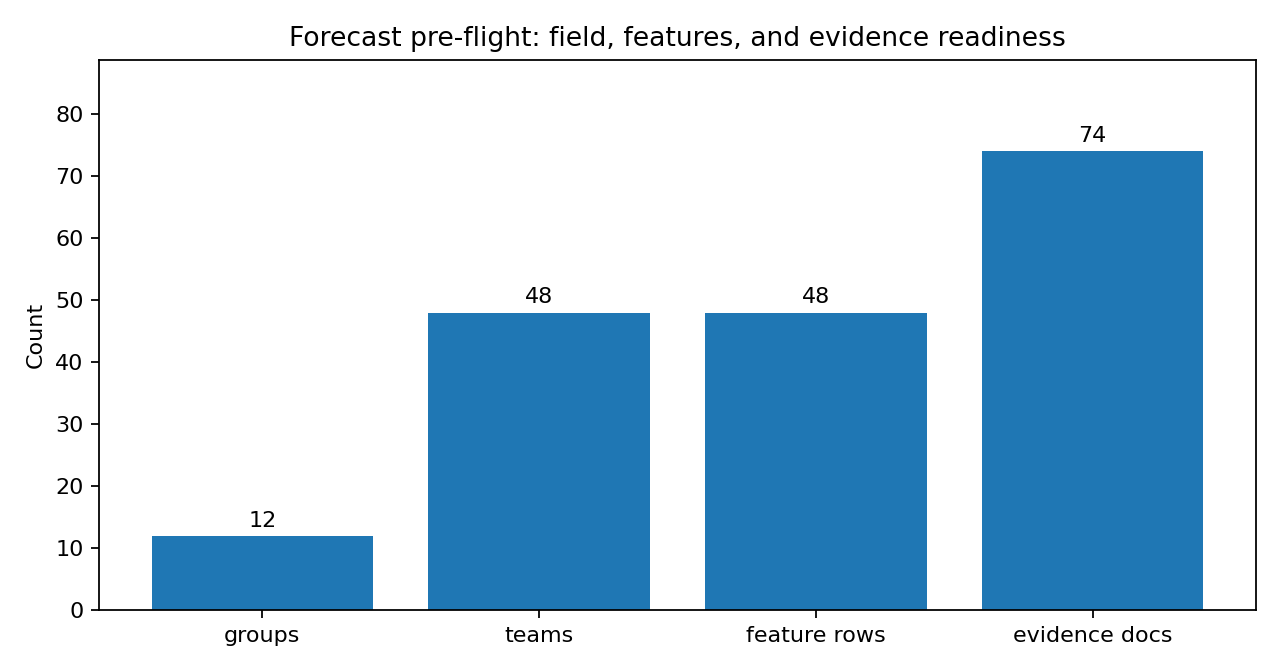

In [11]:
display(Image(filename=str(PROJECT / "figures/preflight_readiness.png")))

Agent Engineering concept: **pre-flight gates** prevent the agent from producing a persuasive answer when the underlying context is not ready.

## 6. Source registry and source-aware forecasting

The deck visualizes the source registry because a forecast agent must be honest about whether it used official facts, demo priors, sample odds, curated notes, or disabled/live adapters.

In [12]:
coverage = story["source_coverage"]
display(pd.DataFrame([coverage["coverage"]]).T.rename(columns={0:"status"}))
display(pd.DataFrame(list(coverage["status_counts"].items()), columns=["source status", "count"]))

,status
field_and_groups,covered_by_official_snapshot
team_priors,bundled_demo_only
market_baseline,bundled_demo_only_not_advice
injuries_lineups,adapter_slot_or_curated_notes_only
historical_calibration,adapter_slot_not_refreshed
rolling_state,supported_when_results_are_supplied


,source status,count
0,bundled_and_refreshable,3
1,bundled_crosscheck,1
2,adapter_placeholder,4
3,manual_or_paid_adapter,1
4,disabled_optional,1
5,bundled_demo_only,1
6,bundled_demo_model,2
7,reference_only,1
8,adapter_placeholder_requires_key,2
9,fallback_adapter_placeholder,1


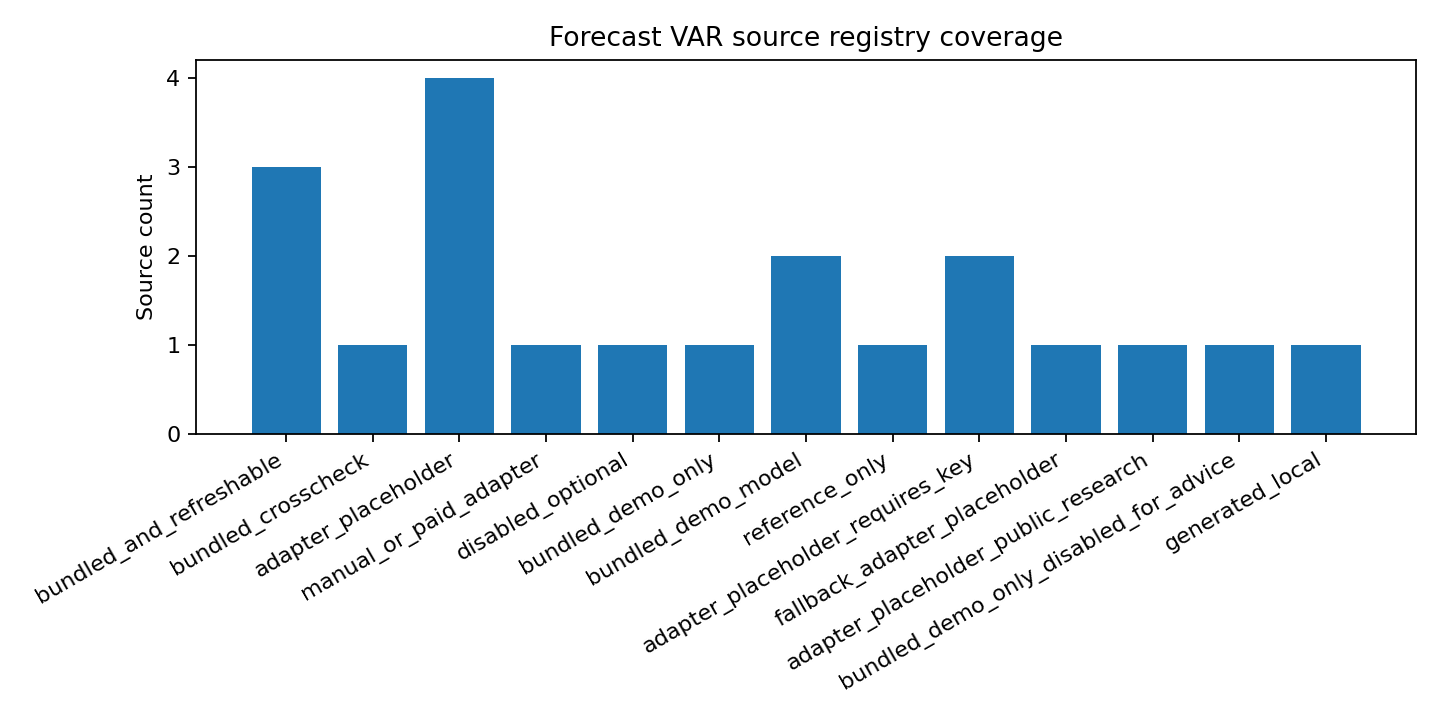

In [13]:
display(Image(filename=str(PROJECT / "figures/source_coverage_status.png")))

## 7. RAG as source-card retrieval

This project intentionally uses lightweight local RAG rather than a complex vector database. The goal of the episode is to make grounding explainable.

In [14]:
from forecast_var.data import search_source_cards
cards = search_source_cards("World Cup 2026 field groups source registry", k=3)
for c in cards:
    print(c["id"], "→", c["title"])
    print("supports:", c.get("supports"))
    print("claim:", c.get("claim"))
    print()

SRC-FIFA-WC26 → FIFA World Cup 2026 official tournament page
supports: ['tournament_field', 'group_membership', 'qualified_team', 'format', 'official_fixture_field']
claim: Official FIFA tournament hub for the 2026 World Cup teams, groups, schedule, venues, and tournament context. This is the primary source for validating the 48-team field before forecasting.

SRC-WIKI-WC26 → 2026 FIFA World Cup cross-check page
supports: ['tournament_field', 'group_membership', 'format', 'crosscheck']
claim: Cross-check page for the 2026 World Cup format, expanded 48-team field, groups, teams, and tournament dates. Use as a secondary sanity check, not as the primary source.

SRC-SOURCE-REGISTRY → Forecast VAR source registry
supports: ['source_policy', 'source_availability', 'adapter_status']
claim: Local registry describing which sources are bundled, refreshable, placeholders, manual or paid adapters, and disabled by default.



A key deck message: **RAG retrieves evidence; it does not prove the answer by itself.** The claim verifier still checks whether the citation has labels that support the claim type.

## 8. Skills: procedural memory

Skills are small procedural modules. They do not contain facts; they tell the agent how to behave.

In [15]:
from pathlib import Path
for skill_path in sorted((PROJECT / ".agents" / "skills").glob("*/SKILL.md")):
    text = skill_path.read_text().splitlines()
    header = "\n".join(text[:6])
    print("---", skill_path.parent.name, "---")
    print(header)
    print()

--- citation-discipline ---
---
name: citation-discipline
description: attach and verify citations for factual, model-derived, scenario, and uncertainty claims. use when the agent answers with source-backed statements, forecast outputs, or evaluation-ready structured claims.
---

# Citation discipline

--- eval-review ---
---
name: eval-review
description: audit forecast-agent responses for the evaluation harness. use when running evals or checking tool use, skill use, citation support, abstention, unsupported claims, and probability sanity.
---

# Eval review

--- forecast-modeling ---
---
name: forecast-modeling
description: use deterministic forecasting tools instead of free-form guessing. use when the user asks for match probabilities, favourites, winners, group forecasts, rankings, monte carlo simulations, rolling forecasts, or model explanations.
---

# Forecast modeling

--- forecast-preflight ---
---
name: forecast-preflight
description: validate the world cup forecasting conte

This aligns with the slide-deck explanation: skills handle source triage, pre-flight checks, citation discipline, forecast modelling, uncertainty calibration, source-adapter governance, Monte Carlo behaviour, and eval review.

## 9. MCP tool boundary

MCP gives the live agent a stable interface to local Python tools. The tool list is visible, inspectable, and easier to evaluate than free-form hidden reasoning.

In [16]:
server_path = PROJECT / "mcp_servers" / "worldcup_forecast" / "server.py"
lines = server_path.read_text().splitlines()
# Print a compact excerpt around the registered tools.
for line in lines[:120]:
    if "@app.tool" in line or line.strip().startswith("def "):
        print(line)

def search_source_cards(query: str, k: int = 5) -> dict:
def preflight_forecast_context() -> dict:
def validate_tournament_field() -> dict:
def get_source_registry() -> dict:
def list_groups() -> dict:
def get_team_inputs(team: str) -> dict:
def forecast_match(team_a: str, team_b: str, adjustments: dict | None = None) -> dict:
def forecast_group(group: str, sims: int = 5000, adjustments: dict | None = None) -> dict:
def rank_teams(limit: int = 10, adjustments: dict | None = None) -> dict:
def explain_model() -> dict:
def verify_claims_against_sources(claims: list[dict]) -> dict:
def refresh_evidence_index(include_live_api: bool = False) -> dict:
def search_evidence_index(query: str, k: int = 8) -> dict:
def source_coverage_report() -> dict:
def extract_market_baseline(team_a: str, team_b: str) -> dict:
def forecast_match_with_context(team_a: str, team_b: str) -> dict:
def simulate_tournament(sims: int = 3000, seed: int = 2026, limit: int = 12) -> dict:


## 10. Model vs market baseline

The deck includes a Group D example where the model is compared against a sample de-vig market baseline. The purpose is not betting; it is to teach model-vs-benchmark comparison.

,team_a,team_b,market_p_team_a_win,market_p_draw,market_p_team_b_win,bookmaker_margin,as_of_utc,warning
0,USA,Australia,0.5216,0.2601,0.2183,0.0533,2026-05-16T00:00:00Z,Illustrative demo market baseline only; not be...


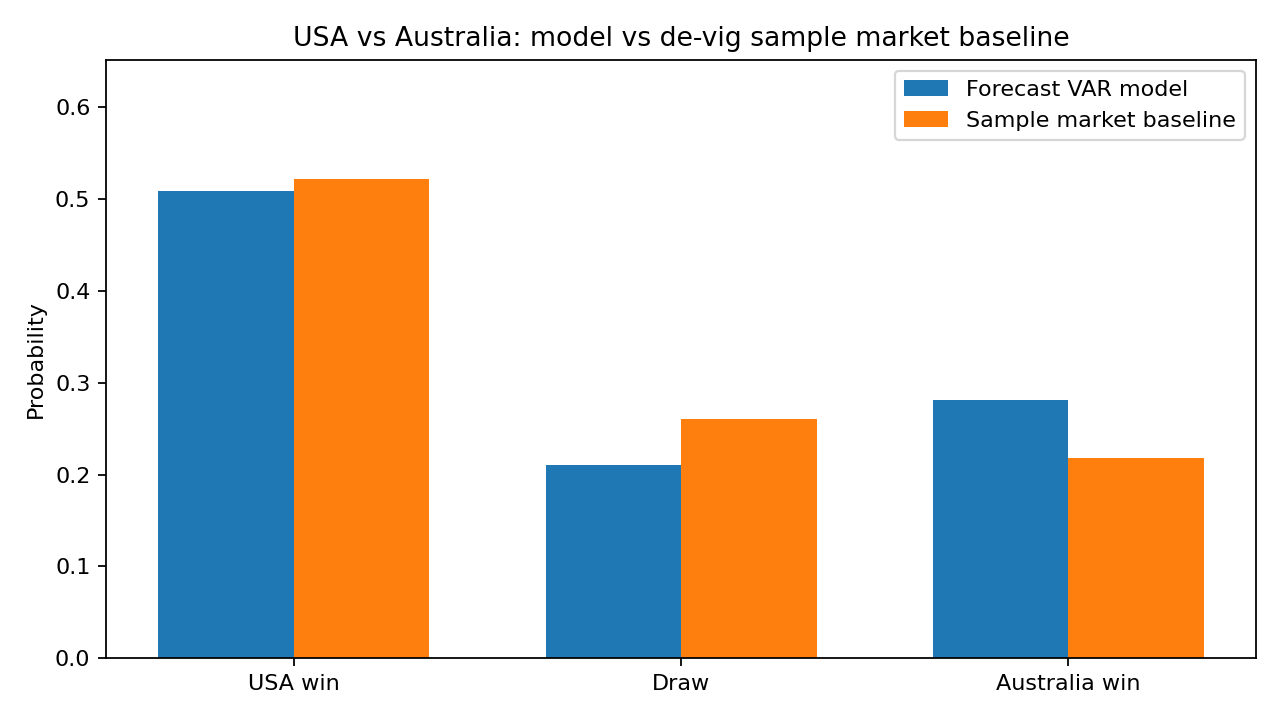

In [17]:
market = story["market_usa_aus"]
display(pd.DataFrame([{k: market[k] for k in ["team_a", "team_b", "market_p_team_a_win", "market_p_draw", "market_p_team_b_win", "bookmaker_margin", "as_of_utc", "warning"]}]))
display(Image(filename=str(PROJECT / "figures/model_vs_market_usa_australia.png")))

## 11. Monte Carlo simulation

Monte Carlo means: run many possible tournaments using probabilistic match outcomes, then count how often each team reaches each stage.

It does **not** mean asking the LLM to predict the tournament repeatedly.

In [18]:
from forecast_var.tools import simulate_tournament
sim = simulate_tournament(sims=300, seed=2026, limit=6)
display(pd.DataFrame(sim["top_teams"])[["team", "round32", "semifinal", "final", "champion"]])

,team,round32,semifinal,final,champion
0,Argentina,0.9767,0.5200,0.3500,0.2033
1,Spain,0.9600,0.4300,0.2733,0.1567
2,France,0.9700,0.4433,0.2633,0.1400
3,England,0.9400,0.3500,0.2067,0.1100
4,Portugal,0.9500,0.3033,0.1600,0.0933
5,Brazil,0.9567,0.2700,0.1267,0.0633


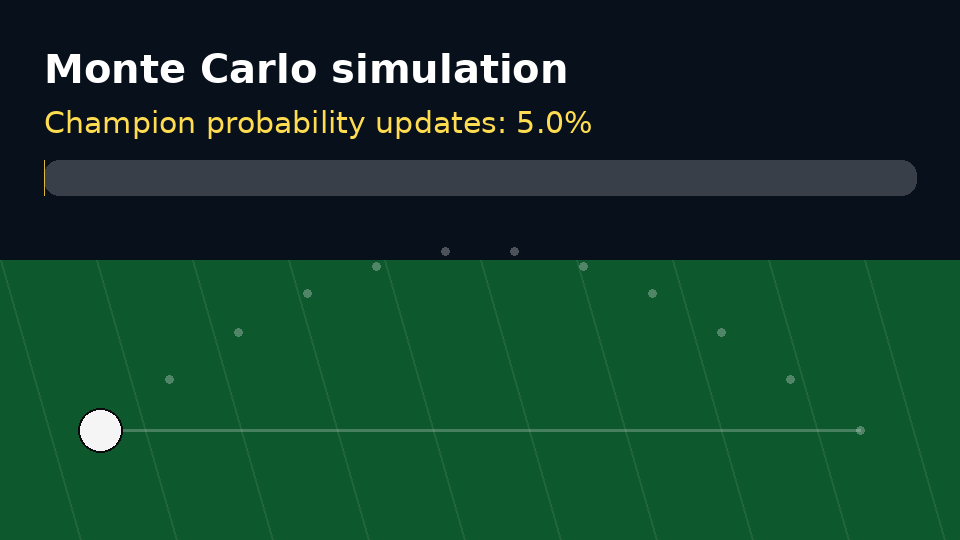

In [19]:
display(Image(filename=str(ASSETS / "monte_carlo_animation.gif")))

## 12. Rolling forecasts

Rolling mode locks completed results and simulates only the remaining fixtures. That is essential once the tournament begins.

In [20]:
rolling = story["rolling_d_after_usa_aus"]
print("Locked result:", rolling["locked_results"])
print("Remaining fixtures:", rolling["remaining_fixtures"])
display(pd.DataFrame(rolling["probabilities"]).T)

Locked result: [{'team_a': 'USA', 'team_b': 'Australia', 'team_a_goals': 2, 'team_b_goals': 1}]
Remaining fixtures: [['USA', 'Paraguay'], ['USA', 'Türkiye'], ['Paraguay', 'Australia'], ['Paraguay', 'Türkiye'], ['Australia', 'Türkiye']]


,winner,top2,top3
USA,0.682,0.906,0.991
Paraguay,0.128,0.403,0.769
Australia,0.016,0.155,0.422
Türkiye,0.174,0.536,0.818


## 13. Evaluation harness

A prediction agent needs more than accuracy. The deck emphasizes behaviour-level checks: tool use, skills, pre-flight, citations, source support, unsupported claim rate, abstention, and probability sanity.

,metric,baseline,Forecast VAR
0,pass_rate,0.000000,1.0
1,tool_recall,0.000000,1.0
2,skill_recall,0.000000,1.0
3,preflight_recall,0.000000,1.0
4,citation_recall,0.000000,1.0
5,source_support_precision,0.000000,1.0
6,unsupported_claim_rate,1.000000,0.0
7,abstention_accuracy,0.714286,1.0
8,probability_sanity_rate,0.428571,1.0


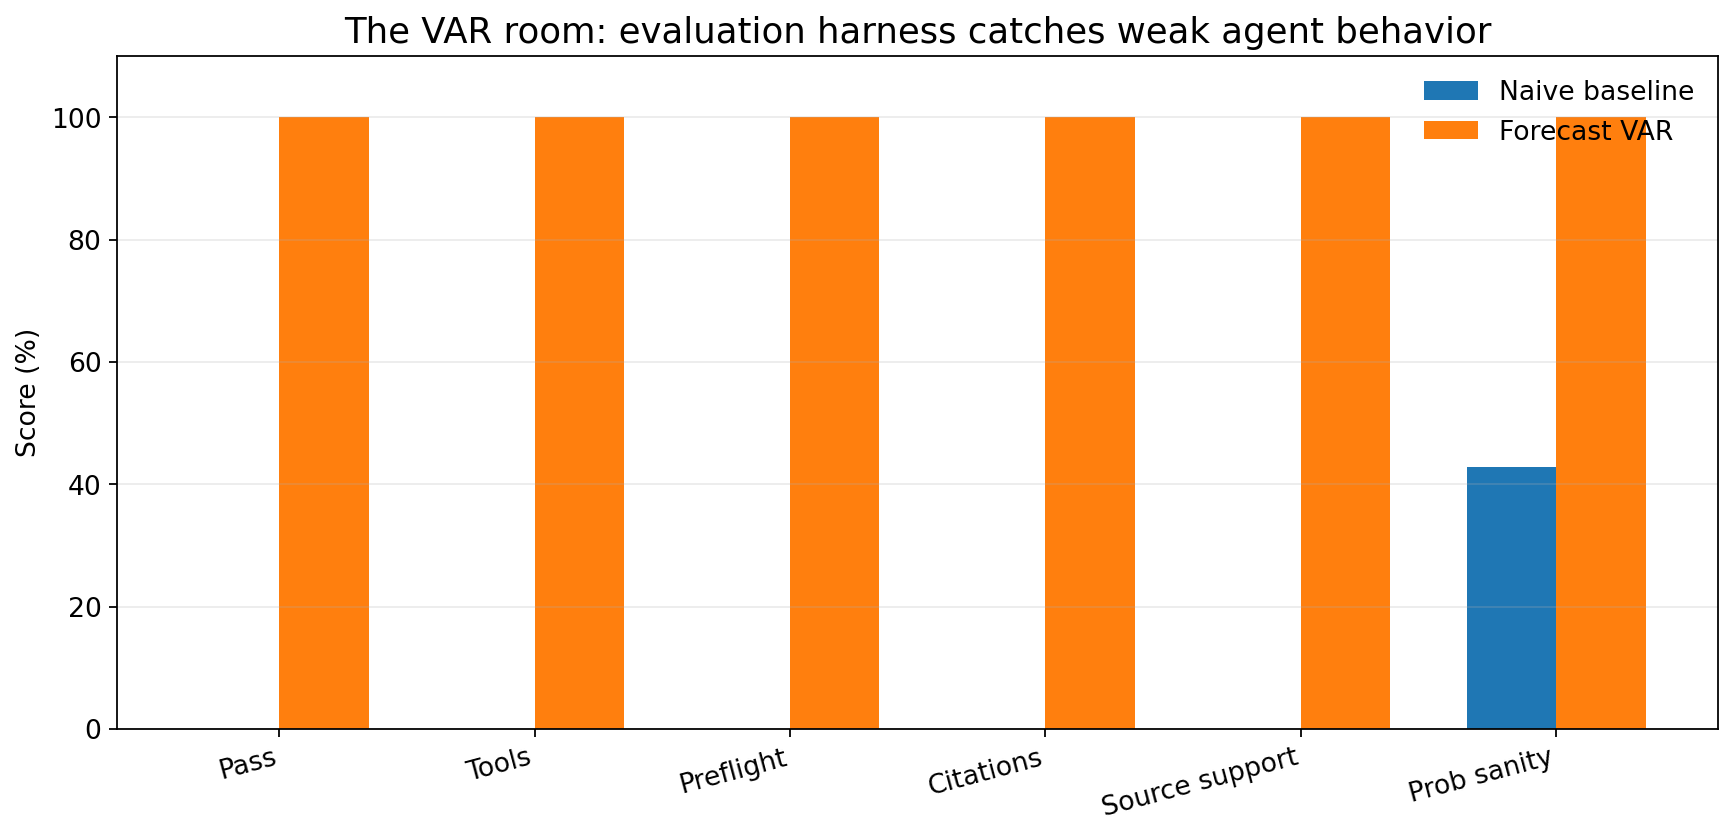

In [21]:
baseline = story["eval_baseline"]
grounded = story["eval_grounded"]
metrics = ["pass_rate", "tool_recall", "skill_recall", "preflight_recall", "citation_recall", "source_support_precision", "unsupported_claim_rate", "abstention_accuracy", "probability_sanity_rate"]
eval_df = pd.DataFrame({"metric": metrics, "baseline": [baseline.get(m) for m in metrics], "Forecast VAR": [grounded.get(m) for m in metrics]})
display(eval_df)
display(Image(filename=str(FIGS / "eval_metrics_comparison.png")))

## 14. What this teaches

The football story gives the session energy. The engineering story gives it substance.

A reliable prediction agent should:

1. Validate the field before forecasting.
2. Retrieve and cite source cards.
3. Use Skills for procedural behaviour.
4. Use MCP tools instead of free-form guessing.
5. Separate factual grounding from model grounding.
6. Type every claim.
7. Verify citation support.
8. Evaluate behaviour, not just final text.
9. Refuse fake certainty.